# Equal-Weight Portfolio Bootstrap Analysis (Comparison)

This notebook analyzes two hedge fund datasets (`time_series_jpm_renamed.csv` and `df_ret_2000.csv`) to:
1. Filter funds with complete data from 2020 to end of 2025.
2. Randomly select funds to form an equal-weight portfolio.
3. Compute various performance metrics (Mean return, CAGR, Volatility, Mean/Std, Max Drawdown, Calmar Ratio, Correlation with S&P 500).
4. Bootstrap this process 1000 times for both datasets.
5. Overlay the distributions and scaling plots to directly compare the two datasets.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [65]:
# Load data
df_jpm = pd.read_csv('data/time_series_jpm_renamed.csv', index_col=0, parse_dates=True)
df_ret = pd.read_csv('data/df_ret_2000.csv', index_col=0, parse_dates=True)

# Load S&P 500 data
sp500 = pd.read_csv('data/hf_returns/sp500.csv', index_col=0, parse_dates=True)

# Filter for the date range: 2020-01-01 to 2025-12-31
start_date = '2020-01-01'
end_date = '2025-12-31'

# Slice the data and drop columns with NaNs
jpm_period = df_jpm.loc[start_date:end_date].dropna(axis=1, how='any')
ret_period = df_ret.loc[start_date:end_date].dropna(axis=1, how='any')
sp500_period = sp500.loc[start_date:end_date]['SP500TR']

print(f"JPM funds with complete data from {start_date} to {end_date}: {jpm_period.shape[1]}")
print(f"df_ret funds with complete data from {start_date} to {end_date}: {ret_period.shape[1]}")

JPM funds with complete data from 2020-01-01 to 2025-12-31: 348
df_ret funds with complete data from 2020-01-01 to 2025-12-31: 354


In [66]:
def calculate_metrics(returns, sp500_returns):
    """
    Calculate portfolio metrics from a series of monthly returns.
    """
    # 1. Mean Return (Annualized)
    mean_return_ann = returns.mean() * 12
    
    # 2. CAGR
    cum_return = (1 + returns).prod()
    n_years = len(returns) / 12
    cagr = cum_return ** (1 / n_years) - 1 if n_years > 0 else np.nan
    
    # 3. Volatility (Annualized)
    volatility = returns.std() * np.sqrt(12)
    
    # 4. Mean / Std (Sharpe Ratio Proxy)
    mean_std_ratio = np.sqrt(12) * returns.mean() / returns.std() if returns.std() != 0 else np.nan
    
    # 5. Max Drawdown
    cum_index = (1 + returns).cumprod()
    running_max = cum_index.cummax()
    drawdown = (cum_index - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # 6. Calmar Ratio
    calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    # 7. Correlation with S&P 500
    correlation = returns.corr(sp500_returns)
    
    return {
        'Mean Return (Ann)': mean_return_ann,
        'CAGR': cagr,
        'Volatility (Ann)': volatility,
        'Mean/Std': mean_std_ratio,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar_ratio,
        'Correlation with SP500': correlation
    }

In [67]:
def run_bootstrap_n(data_df, sp500_series, n, n_boot=1000):
    """Helper to run bootstrap simulation for a given dataframe."""
    cols = data_df.columns.tolist()
    res = []
    if len(cols) < n:
        return pd.DataFrame()
        
    for _ in range(n_boot):
        sel = np.random.choice(cols, size=n, replace=False)
        port_ret = data_df[sel].mean(axis=1)
        res.append(calculate_metrics(port_ret, sp500_series))
    return pd.DataFrame(res)

# Bootstrap 1000 portfolios for n=10
np.random.seed(42) # For reproducibility
n_bootstraps = 1000
n_funds_to_select = 10

res_jpm_10 = run_bootstrap_n(jpm_period, sp500_period, n_funds_to_select, n_bootstraps)
res_ret_10 = run_bootstrap_n(ret_period, sp500_period, n_funds_to_select, n_bootstraps)

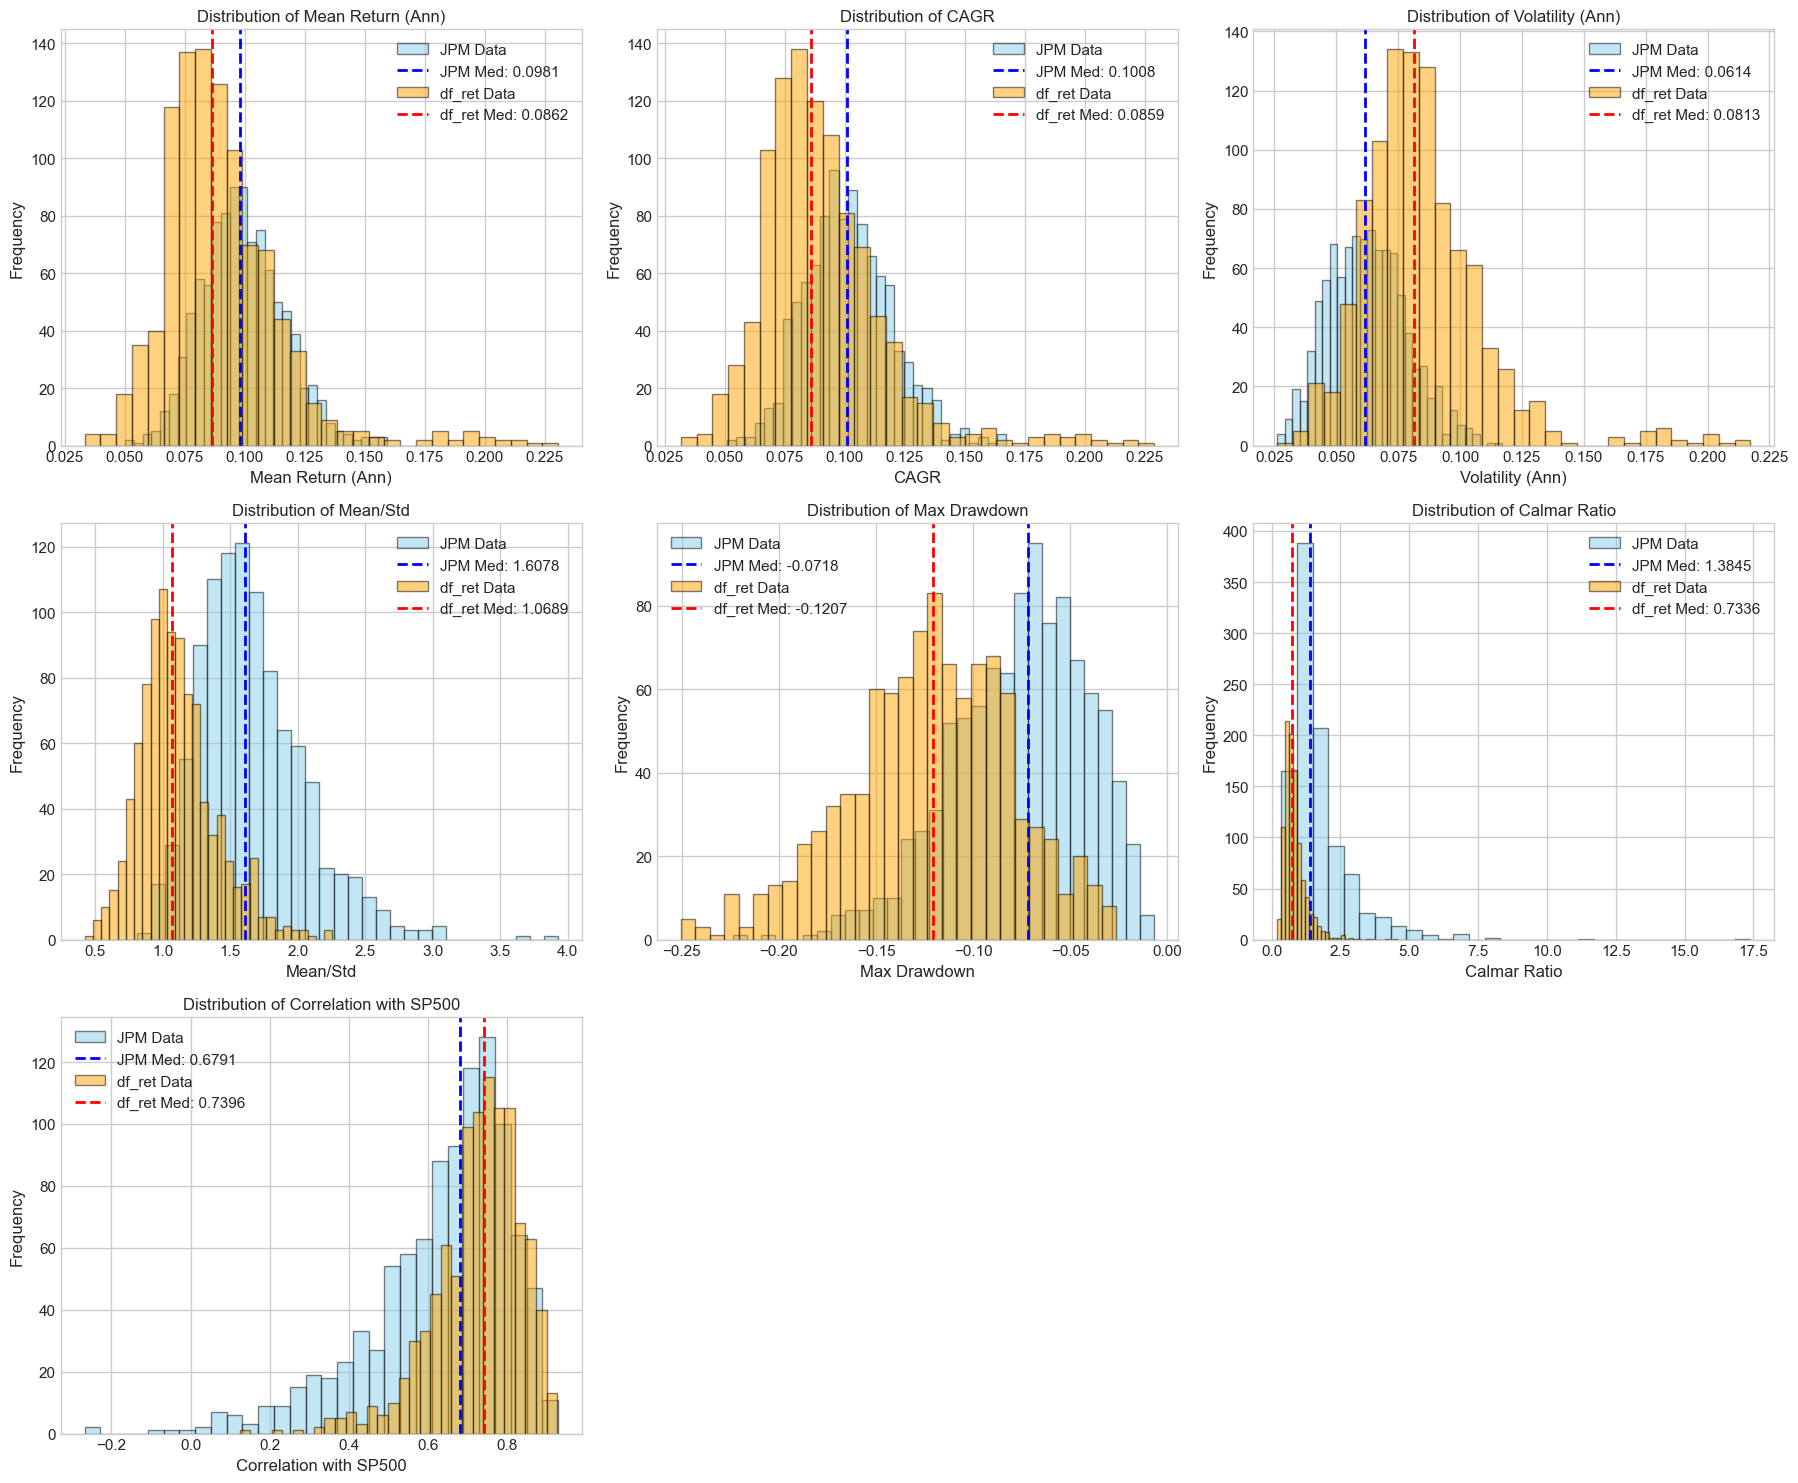

In [68]:
# Plot the distributions for n=10 comparing both datasets
metrics_to_plot = [
    'Mean Return (Ann)', 
    'CAGR', 
    'Volatility (Ann)', 
    'Mean/Std', 
    'Max Drawdown', 
    'Calmar Ratio', 
    'Correlation with SP500'
]

n_metrics = len(metrics_to_plot)
nrows = int(np.ceil(n_metrics / 3))
fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    # JPM Data
    if not res_jpm_10.empty:
        d_jpm = res_jpm_10[metric].dropna()
        ax.hist(d_jpm, bins=30, color='skyblue', edgecolor='black', alpha=0.5, label='JPM Data')
        med_jpm = d_jpm.median()
        ax.axvline(med_jpm, color='blue', linestyle='dashed', linewidth=2, label=f'JPM Med: {med_jpm:.4f}')
        
    # df_ret Data
    if not res_ret_10.empty:
        d_ret = res_ret_10[metric].dropna()
        ax.hist(d_ret, bins=30, color='orange', edgecolor='black', alpha=0.5, label='df_ret Data')
        med_ret = d_ret.median()
        ax.axvline(med_ret, color='red', linestyle='dashed', linewidth=2, label=f'df_ret Med: {med_ret:.4f}')
    
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')
    ax.legend()

# Hide any unused subplots
for i in range(n_metrics, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Iterating Over Portfolio Size ($n$)

In this section, we vary the number of funds in our equal-weight portfolio ($n$) from 3 to 15. 
For each $n$, we run 1000 bootstrap simulations on both datasets.
Then, we extract the **3rd quartile** (for all metrics except SP500 Correlation) and the **1st quartile** (for SP500 Correlation) and overlay the trends for both sets.

In [69]:
n_values = range(3, 16)
metrics_list = metrics_to_plot

q_results_jpm = {m: [] for m in metrics_list}
q_results_ret = {m: [] for m in metrics_list}

np.random.seed(42) # For reproducibility

for n in n_values:
    # Run for JPM
    df_n_jpm = run_bootstrap_n(jpm_period, sp500_period, n, n_bootstraps)
    # Run for df_ret
    df_n_ret = run_bootstrap_n(ret_period, sp500_period, n, n_bootstraps)
    
    # Store the specific quartiles (Q1 for Correlation, Q3 for the rest)
    for m in metrics_list:
        q_target = 0.25 if m == 'Correlation with SP500' else 0.75
        
        if not df_n_jpm.empty:
            q_results_jpm[m].append(df_n_jpm[m].quantile(q_target))
        else:
            q_results_jpm[m].append(np.nan)
            
        if not df_n_ret.empty:
            q_results_ret[m].append(df_n_ret[m].quantile(q_target))
        else:
            q_results_ret[m].append(np.nan)

# Convert results to DataFrame for easy plotting
df_q_jpm = pd.DataFrame(q_results_jpm, index=n_values)
df_q_ret = pd.DataFrame(q_results_ret, index=n_values)

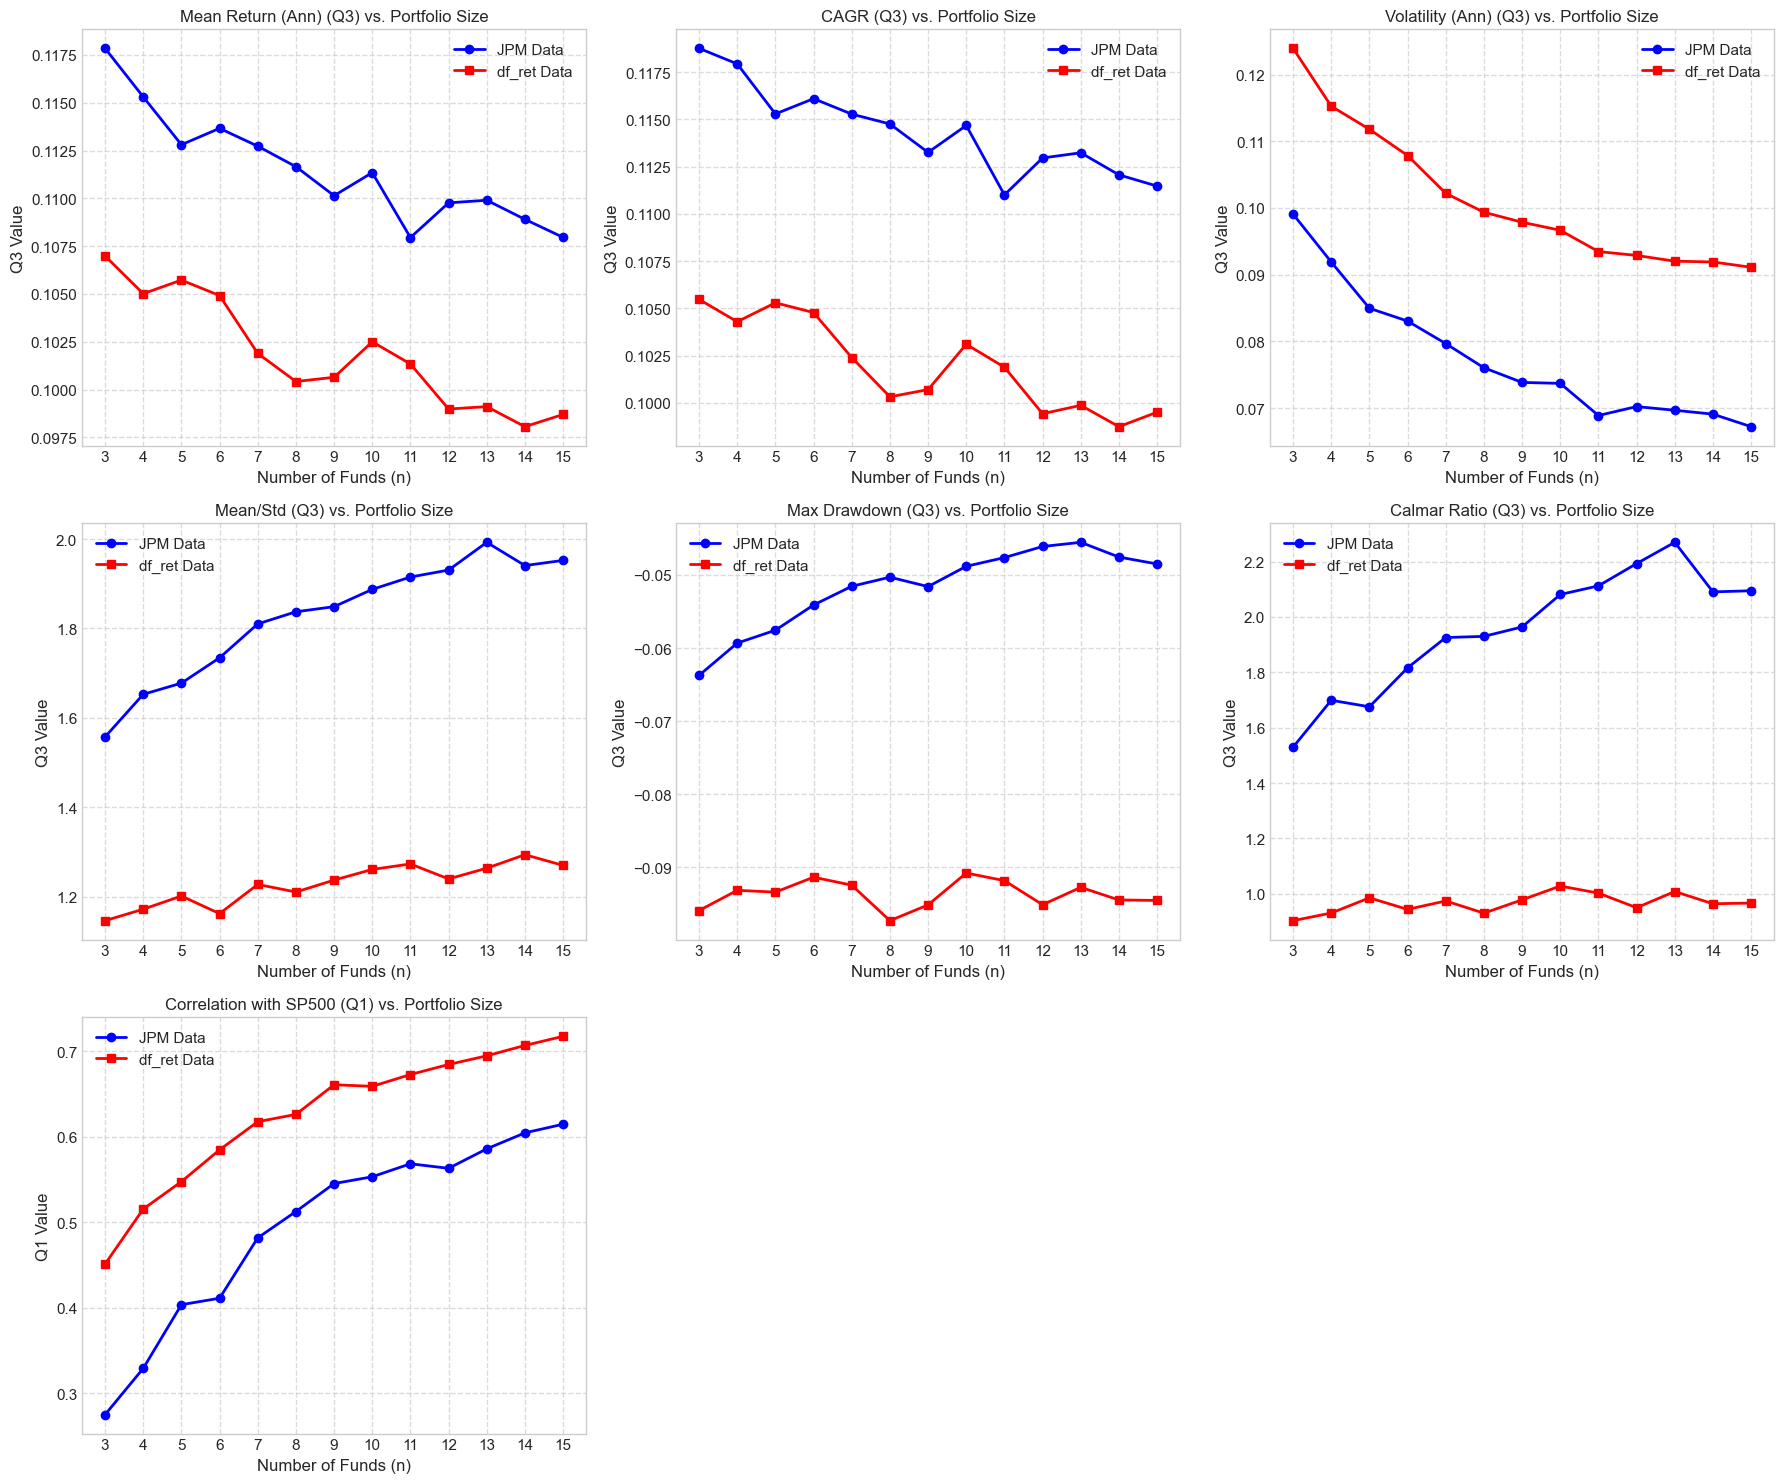

In [70]:
# Plot the scaling results comparing both datasets
nrows_scale = int(np.ceil(len(metrics_list) / 3))
fig, axes = plt.subplots(nrows_scale, 3, figsize=(18, 5 * nrows_scale))
axes = axes.flatten()

for i, metric in enumerate(metrics_list):
    ax = axes[i]
    
    ax.plot(df_q_jpm.index, df_q_jpm[metric], marker='o', linestyle='-', color='blue', linewidth=2, label='JPM Data')
    ax.plot(df_q_ret.index, df_q_ret[metric], marker='s', linestyle='-', color='red', linewidth=2, label='df_ret Data')
    
    q_label = "Q1" if metric == 'Correlation with SP500' else "Q3"
    ax.set_title(f'{metric} ({q_label}) vs. Portfolio Size')
    ax.set_xlabel('Number of Funds (n)')
    ax.set_ylabel(f'{q_label} Value')
    ax.set_xticks(list(n_values))
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

# Hide any unused subplots
for i in range(len(metrics_list), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()